# Partial dependence / Individual Conditional Expectation (PD/ICE) Explainer Demo

This example demonstrates how to interpret a **scikit-learn** model using
the H2O Sonar library and retrieve the data and **partial dependence plot**.

In [1]:
import logging
import os

import pandas
import datatable
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons, explainers
from h2o_sonar.lib.api.models import ModelApi
from h2o_sonar.explainers.pd_ice_explainer import PdIceExplainer

from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# dataset
dataset_path = "../../data/predictive/creditcard.csv"
target_col = "default payment next month"
df = pandas.read_csv(dataset_path)
(X, y) = df.drop(target_col, axis=1), df[target_col]

# results
results_location = "../../results"
os.makedirs(results_location, exist_ok=True)

In [3]:
# explainer description
interpret.describe_explainer(PdIceExplainer)

{'id': 'h2o_sonar.explainers.pd_ice_explainer.PdIceExplainer',
 'name': 'PdIceExplainer',
 'display_name': 'Partial Dependence Plot',
 'tagline': 'PdIceExplainer.',
 'description': 'Partial dependence plot (PDP) portrays the average prediction\nbehavior of the model across the domain of an input variable along with +/- 1\nstandard deviation bands. Individual Conditional Expectations plot (ICE) displays\nthe prediction behavior for an individual row of data when an input variable is\ntoggled across its domain.\n\nPD binning:\n\n**Integer** feature:\n\n* bins in **numeric** mode:\n    * bins are integers\n    * (at most) `grid_resolution` integer values in between minimum and maximum\n      of feature values\n    * bin values are created as evenly as possible\n    * minimum and maximum is included in bins\n      (if `grid_resolution` is bigger or equal to 2)\n* bins in **categorical** mode:\n    * bins are integers\n    * top `grid_resolution` values from feature values ordered by freque

## Interpretation

In [4]:
# scikit-learn model
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
gradient_booster.fit(X, y)

# explainable model
model = ModelApi().create_model(target_col=target_col, model_src=gradient_booster, used_features=X.columns.to_list())

interpretation = interpret.run_interpretation(
    dataset=df,
    model=model,
    target_col=target_col,
    results_location=results_location,
    log_level=logging.INFO,
    explainers=[
        commons.ExplainerToRun(
            explainer_id=PdIceExplainer.explainer_id(),
            params="",
        )
    ]
)

/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from ragas.metrics._answer_correctness import AnswerCorrectness, answer_correctness
/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic 

## Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(PdIceExplainer.explainer_id())

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.pd_ice_explainer.PdIceExplainer',
 'name': 'PdIceExplainer',
 'display_name': 'Partial Dependence Plot',
 'tagline': 'PdIceExplainer.',
 'description': 'Partial dependence plot (PDP) portrays the average prediction\nbehavior of the model across the domain of an input variable along with +/- 1\nstandard deviation bands. Individual Conditional Expectations plot (ICE) displays\nthe prediction behavior for an individual row of data when an input variable is\ntoggled across its domain.\n\nPD binning:\n\n**Integer** feature:\n\n* bins in **numeric** mode:\n    * bins are integers\n    * (at most) `grid_resolution` integer values in between minimum and maximum\n      of feature values\n    * bin values are created as evenly as possible\n    * minimum and maximum is included in bins\n      (if `grid_resolution` is bigger or equal to 2)\n* bins in **categorical** mode:\n    * bins are integers\n    * top `grid_resolution` values from feature values ordered by freque

In [8]:
# parameters
result.params()

{'sample_size': 25000,
 'max_features': 10,
 'features': None,
 'oor_grid_resolution': 0,
 'quantile-bin-grid-resolution': 0,
 'grid_resolution': 20,
 'center': False,
 'sort_bins': True,
 'histograms': True,
 'quantile-bins': '',
 'numcat_num_chart': True,
 'numcat_threshold': 11,
 'debug_residuals': False}

### Display PD Data

In [9]:
result.data(feature_name="EDUCATION")

,bin,frequency,pd,sd,oor
,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪
0,0,3,0.2227,0.416079,0
1,1,3714,0.2227,0.416079,0
2,2,4588,0.3414,0.474203,0
3,3,1590,0.3414,0.474203,0
4,4,26,0.3414,0.474203,0
5,5,79,0.2298,0.420725,0
6,6,NA,0.2298,0.420725,0


In [10]:
result.data(feature_name="PAY_3")

,bin,frequency,pd,sd,oor
,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪
0,−2,1292,0.3048,0.460346,0
1,−1,2143,0.3048,0.460346,0
2,0,5125,0.3048,0.460346,0
3,1,3,0.3271,0.469178,0
4,2,1306,0.326,0.468771,0
5,3,58,0.3259,0.468734,0
6,4,31,0.3259,0.468734,0
7,5,13,0.3259,0.468734,0
8,6,12,0.3259,0.468734,0


### Plot PD Data

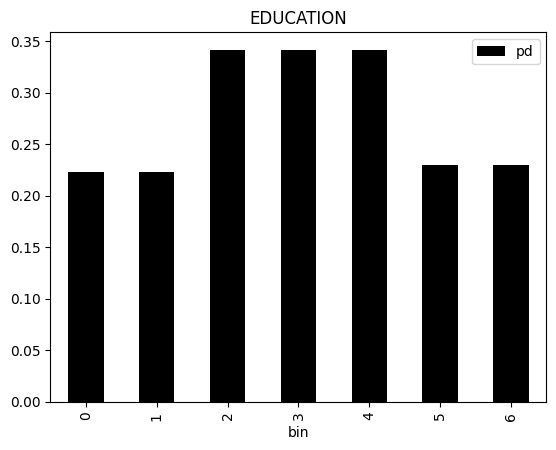

In [11]:
result.plot(feature_name="EDUCATION", override_feature_type=result.format.KEY_CATEGORICAL)

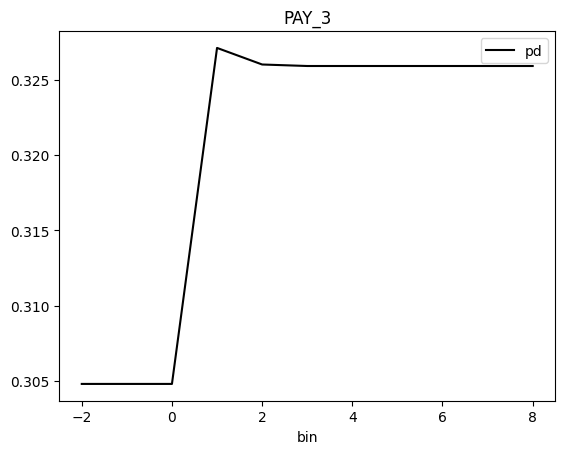

In [12]:
result.plot(feature_name="PAY_3")

### Save Explainer Log and Data

In [13]:
# save the explainer log
result.log(path="./pd-ice-demo.log")

In [14]:
!head pd-ice-demo.log

2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 BEGIN calculation
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 loading dataset
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 loaded dataset has 10000 rows and 25 columns
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 getting features list, importance and metadata
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 all most important model features: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
2026-01-29 16:11:38,082 IN

In [15]:
# save the explainer data
result.zip(file_path="./pd-ice-demo-archive.zip")

In [16]:
!unzip -l pd-ice-demo-archive.zip

Archive:  pd-ice-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
    11536  2026-01-29 16:11   explainer_h2o_sonar_explainers_pd_ice_explainer_PdIceExplainer_cba719fb-5061-483d-add5-79c4175d2b25/result_descriptor.json
      151  2026-01-29 16:11   explainer_h2o_sonar_explainers_pd_ice_explainer_PdIceExplainer_cba719fb-5061-483d-add5-79c4175d2b25/global_partial_dependence/application_json.meta
     6978  2026-01-29 16:11   explainer_h2o_sonar_explainers_pd_ice_explainer_PdIceExplainer_cba719fb-5061-483d-add5-79c4175d2b25/global_partial_dependence/application_json/explanation.json
      929  2026-01-29 16:11   explainer_h2o_sonar_explainers_pd_ice_explainer_PdIceExplainer_cba719fb-5061-483d-add5-79c4175d2b25/global_partial_dependence/application_json/pd_feature_3_class_0.json
     2557  2026-01-29 16:11   explainer_h2o_sonar_explainers_pd_ice_explainer_PdIceExplainer_cba719fb-5061-483d-add5-79c4175d2b25/global_partial_dependence/application_json/pd_